### 00_Setup_e_Instalacion
Instalación de dependencias necesarias para correr el notebook de punta a punta.

In [9]:
import sys
import os
# Celda de Setup Definitiva - Actualizar paquetes compatibles
!{sys.executable} -m pip install --upgrade pandas pyarrow scikit-learn numpy matplotlib --quiet

# Crear directorio de salida si no existe
os.makedirs('processed', exist_ok=True)

print("✓ Paquetes instalados correctamente")

✓ Paquetes instalados correctamente



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 01. Carga y Limpieza de Datos
En esta etapa inicial, realizamos la ingesta y preparación del log de eventos para garantizar la integridad de los datos antes de proceder al análisis. El objetivo es estructurar la información cruda en un formato listo para el modelado:
- **Carga y control:** Lectura de datos crudos (`events.csv`) y validación de estructura.
- **Transformación temporal:** Conversión de *timestamps* a formato `datetime` para habilitar análisis de cohortes y series temporales.
- **Auditoría de integridad:** Cruce de eventos con IDs de transacción para verificar consistencia.
- **Exportación:** Generación del archivo limpio (`events_clean.csv`) como fuente de verdad para los siguientes pasos.

In [10]:
import pandas as pd
import os

# Crear directorio de salida si no existe
os.makedirs('processed', exist_ok=True)

# Leer el archivo CSV
file_path = "./events.csv"
events_df = pd.read_csv(file_path, low_memory=False)

print(events_df.head())
print(events_df.info()) 

# Contar visitantes únicos con transacciones
print(events_df[events_df['event'] == 'transaction']['visitorid'].nunique())

# Convertir el timestamp a datetime
events_df["timestamp"] = pd.to_datetime(events_df["timestamp"], unit="ms") 
print(events_df['timestamp'].dtype)
fecha_min = events_df["timestamp"].min() 
fecha_max = events_df["timestamp"].max() 
print("Fecha mínima:", fecha_min)
print("Fecha máxima:", fecha_max)

# Cruzar los eventos con la presencia de transactionid
print(pd.crosstab(events_df['event'], events_df['transactionid'].notnull()))

# Exportar a formato CSV en su lugar (evita el error de Arrow)
events_df.to_csv("processed/events_clean.csv", index=False)
print("Script 01 terminado: Archivo 'events_clean.csv' guardado con éxito.")

       timestamp  visitorid event  itemid  transactionid
0  1433221332117     257597  view  355908            NaN
1  1433224214164     992329  view  248676            NaN
2  1433221999827     111016  view  318965            NaN
3  1433221955914     483717  view  253185            NaN
4  1433221337106     951259  view  367447            NaN
<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 116.1 MB
None
11719
datetime64[ms]
Fecha mínima: 2015-05-03 03:00:04.384000
Fecha máxima: 2015-09-18 02:59:47.788000
transactionid    False  True 
event                        
addtocart        69332      0
transaction          0  22457
view           2664312      0
Script 01 terminado: Archivo 'events_clean.

### 02. Feature Engineering y Definición del Target
Construcción de la matriz de características y la variable objetivo para modelos predictivos:
- **Ventanas temporales:** División de los datos en período de *features* (agosto) y período *target* (primera semana de septiembre).
- **Variables base:** Agregación de eventos por usuario (vistas, *add-to-cart*, transacciones, días activos y recencia).
- **Features derivadas:** Cálculo de ratios de conversión, índice de intención de compra y flags binarias.
- **Variable Target:** Etiquetado predictivo indicando si el usuario compró o no en la ventana futura.
- **Exportación:** Guardado del dataset consolidado (`features_and_target.csv`).

In [11]:
import pandas as pd
import numpy as np
import os

# Crear directorio de salida si no existe
os.makedirs('processed', exist_ok=True)

print("Cargando eventos limpios...")
events = pd.read_csv("processed/events_clean.csv")

if events["timestamp"].dtype in [np.int64, np.float64]:
    events["timestamp"] = pd.to_datetime(events["timestamp"], unit='ms')
else:
    events["timestamp"] = pd.to_datetime(events["timestamp"])

inicio_features = "2015-08-01 00:00:00"
fin_features    = "2015-08-30 23:59:59"
inicio_target   = "2015-08-31 00:00:00"
fin_target      = "2015-09-06 23:59:59"
fecha_corte     = pd.Timestamp(fin_features)

print(f"-> Ventana de features: {inicio_features} a {fin_features}")
print(f"-> Ventana de target:   {inicio_target} a {fin_target}")

df_features_period = events[
    (events["timestamp"] >= inicio_features) &
    (events["timestamp"] <= fin_features)
].copy()

df_target_period = events[
    (events["timestamp"] >= inicio_target) &
    (events["timestamp"] <= fin_target)
].copy()

# --- MATRIZ BASE (un solo escaneo) ---
matriz_feature = pd.crosstab(
    index=df_features_period["visitorid"],
    columns=df_features_period["event"]
).reset_index()

matriz_feature.rename(columns={
    "view": "total_pageviews",
    "addtocart": "total_addtocart",
    "transaction": "total_transacciones"
}, inplace=True)

for col in ["total_pageviews", "total_addtocart", "total_transacciones"]:
    if col not in matriz_feature.columns:
        matriz_feature[col] = 0

matriz_feature["total_eventos"] = (
    matriz_feature["total_pageviews"] +
    matriz_feature["total_addtocart"] +
    matriz_feature["total_transacciones"]
)

# --- DÍAS ACTIVOS ---
df_features_period["fecha"] = df_features_period["timestamp"].dt.date
df_dias = df_features_period.groupby("visitorid")["fecha"].nunique().reset_index()
df_dias.rename(columns={"fecha": "dias_activos"}, inplace=True)
matriz_feature = matriz_feature.merge(df_dias, on="visitorid", how="left")
matriz_feature["dias_activos"] = matriz_feature["dias_activos"].fillna(1)

# --- RECENCIA (un solo groupby sobre df_features_period) ---
df_recencia = df_features_period.groupby("visitorid")["timestamp"].max().reset_index()
df_recencia["recencia_dias"] = (
    (fecha_corte - df_recencia["timestamp"]).dt.total_seconds() / 86400
).clip(lower=0)
df_recencia = df_recencia[["visitorid", "recencia_dias"]]
matriz_feature = matriz_feature.merge(df_recencia, on="visitorid", how="left")
matriz_feature["recencia_dias"] = matriz_feature["recencia_dias"].fillna(30.0)

# --- FEATURES DERIVADAS DIRECTAMENTE DE LO QUE YA TENEMOS ---
# ratio_conversion: transacciones pasadas / pageviews
matriz_feature["ratio_conversion"] = (
    matriz_feature["total_transacciones"] / matriz_feature["total_pageviews"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

# ratio_intent: add-to-cart / pageviews (calculado sobre columnas ya existentes)
matriz_feature["ratio_intent"] = (
    matriz_feature["total_addtocart"] / (matriz_feature["total_pageviews"] + 1)
)

# tuvo_addtocart: binaria derivada directamente de total_addtocart
matriz_feature["tuvo_addtocart"] = (matriz_feature["total_addtocart"] > 0).astype(int)

# --- TARGET ---
compradores_futuros = df_target_period[
    df_target_period["event"] == "transaction"
]["visitorid"].unique()

matriz_feature["target"] = matriz_feature["visitorid"].isin(compradores_futuros).astype(int)

print("\n=== MATRIZ COMPLETA ===")
print("Dimensiones:", matriz_feature.shape)
print("Distribución target:\n", matriz_feature["target"].value_counts())
print(f"Tasa de conversión: {matriz_feature['target'].mean() * 100:.4f}%")

matriz_feature.to_csv("processed/features_and_target.csv", index=False)
print("\n[OK] Guardado en 'processed/features_and_target.csv'")

Cargando eventos limpios...
-> Ventana de features: 2015-08-01 00:00:00 a 2015-08-30 23:59:59
-> Ventana de target:   2015-08-31 00:00:00 a 2015-09-06 23:59:59

=== MATRIZ COMPLETA ===
Dimensiones: (300861, 11)
Distribución target:
 target
0    300761
1       100
Name: count, dtype: int64
Tasa de conversión: 0.0332%

[OK] Guardado en 'processed/features_and_target.csv'


### 03. Entrenamiento y Evaluación del Modelo
Entrenamiento de un modelo de clasificación para predecir la intención de compra:
- **División y Blindaje:** Split de datos (train/test estratificado) aplicando *undersampling* exclusivamente en train para evitar filtración de información.
- **Modelado:** Entrenamiento de un *Random Forest Classifier* (`n_estimators=200`) sobre el set balanceado.
- **Optimización de Umbrales:** Evaluación sistemática de métricas (Precision, Recall, F1) variando el umbral de decisión para adaptarlo al negocio.
- **Explicabilidad:** Extracción de *Feature Importances* y generación de curvas de rendimiento (*Precision-Recall*) para auditoría de variables.

Cargando matriz de features y target...

Distribución original en Train: [210532     70]
Distribución balanceada en Train: [70 70]
Distribución real intacta en Test: [90229    30]

=== PASO 4: ENTRENAMIENTO ===
[OK] Modelo Random Forest entrenado exitosamente.

=== PASO 5: EVALUACIÓN ===

--- UMBRAL DEFAULT (0.5) ---
[[67175 23054]
 [    9    21]]
              precision    recall  f1-score   support

           0       1.00      0.74      0.85     90229
           1       0.00      0.70      0.00        30

    accuracy                           0.74     90259
   macro avg       0.50      0.72      0.43     90259
weighted avg       1.00      0.74      0.85     90259

ROC-AUC Score: 0.8651

--- ANÁLISIS DE UMBRALES EN COMPORTAMIENTO ---
  Umbral |   TP |     FP |   FN |  Precision |  Recall |     F1
-----------------------------------------------------------------
    0.05 |   30 |  67606 |    0 |     0.0004 |  1.0000 | 0.0009
    0.10 |   29 |  54673 |    1 |     0.0005 |  0.9667 | 0.

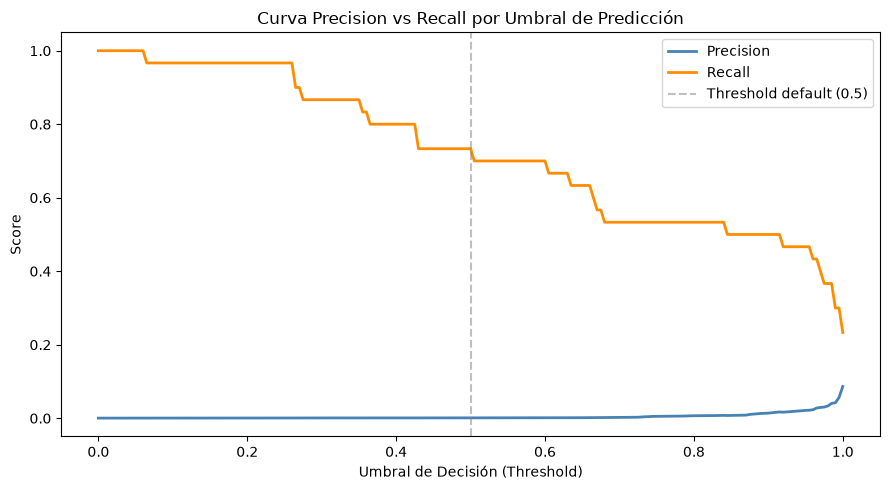

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score, precision_recall_curve, precision_score, recall_score, f1_score
from sklearn.utils import resample

# 1. CARGA DE DATOS
print("Cargando matriz de features y target...")
df_completo = pd.read_csv("processed/features_and_target.csv")

# Separar variables de entrenamiento (X) y objetivo (y)
# Eliminamos 'visitorid' porque es un identificador, no una feature predictiva
X = df_completo.drop(columns=["visitorid", "target"])
y = df_completo["target"]

# 2. TRAIN/TEST SPLIT (Mantenemos la distribución desbalanceada real en Test para auditar el negocio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. UNDERSAMPLING SOLO EN TRAIN (Blindaje estricto contra fugas de información)
print(f"\nDistribución original en Train: {np.bincount(y_train)}")

X_train_df = pd.DataFrame(X_train)
X_train_df['target'] = y_train

df_majority = X_train_df[X_train_df['target'] == 0]
df_minority = X_train_df[X_train_df['target'] == 1]

# Submuestreamos la clase mayoritaria (0) para igualar a la minoritaria (1)
df_majority_downsampled = resample(df_majority, 
                                   replace=False,    
                                   n_samples=len(df_minority), 
                                   random_state=42)

df_balanced = pd.concat([df_majority_downsampled, df_minority])
X_train_final = df_balanced.drop(columns=['target'])
y_train_final = df_balanced['target']

print(f"Distribución balanceada en Train: {np.bincount(y_train_final)}")
print(f"Distribución real intacta en Test: {np.bincount(y_test)}")

# 4. ENTRENAMIENTO
print("\n=== PASO 4: ENTRENAMIENTO ===")
modelo = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo.fit(X_train_final, y_train_final)
print("[OK] Modelo Random Forest entrenado exitosamente.")

# 5. EVALUACIÓN CON ANÁLISIS DE UMBRALES
print("\n=== PASO 5: EVALUACIÓN ===")
y_proba = modelo.predict_proba(X_test)[:, 1]

# Métricas con threshold default (0.5) para tener la referencia básica
y_pred_default = modelo.predict(X_test)
print("\n--- UMBRAL DEFAULT (0.5) ---")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Análisis sistemático de umbrales para optimización del negocio
print("\n--- ANÁLISIS DE UMBRALES EN COMPORTAMIENTO ---")
print(f"{'Umbral':>8} | {'TP':>4} | {'FP':>6} | {'FN':>4} | {'Precision':>10} | {'Recall':>7} | {'F1':>6}")
print("-" * 65)

umbrales_a_evaluar = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

for umbral in umbrales_a_evaluar:
    y_pred_t = (y_proba >= umbral).astype(int)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    recall    = recall_score(y_test, y_pred_t, zero_division=0)
    f1        = f1_score(y_test, y_pred_t, zero_division=0)
    tp        = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp        = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn        = ((y_pred_t == 0) & (y_test == 1)).sum()

    print(f"{umbral:>8.2f} | {tp:>4} | {fp:>6} | {fn:>4} | {precision:>10.4f} | {recall:>7.4f} | {f1:>6.4f}")

# 6. IMPORTANCIA DE FEATURES
print("\n=== PASO 6: IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCE) ===")
importancias = pd.Series(
    modelo.feature_importances_, index=X.columns
).sort_values(ascending=False)
print(importancias.round(4))

# 7. CURVA PRECISION / RECALL
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precision_vals[:-1], label="Precision", color="steelblue", lw=2)
plt.plot(thresholds, recall_vals[:-1],    label="Recall",    color="darkorange", lw=2)
plt.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Threshold default (0.5)")
plt.xlabel("Umbral de Decisión (Threshold)")
plt.ylabel("Score")
plt.title("Curva Precision vs Recall por Umbral de Predicción")
plt.legend()
plt.tight_layout()
plt.show()